
Error Analysis Table
Shots	Theta	Estimate	Error
----------------------------------------
100	0.5625	0.4282	0.1343
215	0.5625	0.4513	0.1112
464	0.5625	0.4351	0.1274
1000	0.5625	0.4367	0.1258
2154	0.5625	0.4387	0.1238
4641	0.5625	0.4396	0.1229
10000	0.5625	0.4367	0.1258
21544	0.5625	0.4390	0.1235
46415	0.5625	0.4365	0.1260
100000	0.5625	0.4380	0.1245
100	0.1234	0.1266	0.0032
215	0.1234	0.1131	0.0103
464	0.1234	0.1250	0.0016
1000	0.1234	0.1279	0.0045
2154	0.1234	0.1284	0.0050
4641	0.1234	0.1226	0.0008
10000	0.1234	0.1236	0.0002
21544	0.1234	0.1219	0.0015
46415	0.1234	0.1247	0.0013
100000	0.1234	0.1232	0.0002


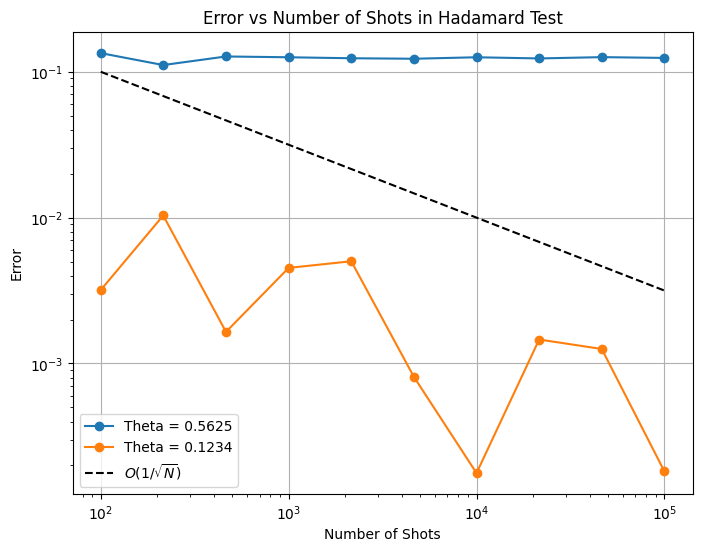

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import CPhaseGate
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

def hadamard_test(theta):
    """
    Perform the Hadamard test for a controlled phase gate with angle theta.
    """
    # Define the controlled phase gate
    controlled_gate = CPhaseGate(2 * np.pi * theta, label='U')
    
    # Define the quantum and classical registers
    q = QuantumRegister(2, 'q')
    c = ClassicalRegister(1, 'c')
    qc = QuantumCircuit(q, c)
    
    # Hadamard test sequence
    qc.h(q[0])
    qc.x(q[1])
    qc.append(controlled_gate, [q[0], q[1]])
    qc.h(q[0])
    qc.measure(q[0], c[0])
    
    return qc

# Define simulator
aer_sim = AerSimulator()

def run_hadamard_test(theta, num_shots):
    """Run the Hadamard test circuit on a simulator and compute error."""
    qc = hadamard_test(theta)
    
    # Transpile the circuit
    pm = generate_preset_pass_manager(backend=aer_sim, optimization_level=1)
    qc_transpiled = pm.run(qc)
    
    # Run the circuit using a sampler
    sampler = Sampler(aer_sim)
    result = sampler.run([qc_transpiled], shots=num_shots).result()
    
    # Retrieve measurement counts
    counts = result[0].data.c.get_counts()
    P_0 = counts.get('0', 0) / num_shots
    
    # Compute Re(<psi|U|psi>) and estimate theta
    Re_psi_Upsi = 2 * P_0 - 1
    theta_estimate = np.arccos(Re_psi_Upsi) / (2 * np.pi)
    error = abs(theta - theta_estimate)
    return theta_estimate, error

# Define test cases
theta_values = [0.5625, 0.1234]
num_shots_list = np.logspace(2, 5, num=10, dtype=int)

def plot_error_vs_shots():
    """Plot error vs number of shots for both theta cases and display error table."""
    plt.figure(figsize=(8,6))
    
    print("\nError Analysis Table")
    print("Shots\tTheta\tEstimate\tError")
    print("-" * 40)
    
    for theta in theta_values:
        errors = []
        for num_shots in num_shots_list:
            theta_estimate, error = run_hadamard_test(theta, num_shots)
            errors.append(error)
            print(f"{num_shots}\t{theta:.4f}\t{theta_estimate:.4f}\t{error:.4f}")
        
        plt.plot(num_shots_list, errors, label=f"Theta = {theta}", marker='o')
    
    plt.plot(num_shots_list, 1/np.sqrt(num_shots_list), 'k--', label=r'$O(1/\sqrt{N})$')
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel("Number of Shots")
    plt.ylabel("Error")
    plt.legend()
    plt.title("Error vs Number of Shots in Hadamard Test")
    plt.grid(True)
    plt.show()

# Run the analysis
plot_error_vs_shots()
